# 9. Reward Landscape Visualisation

Purpose: stop tuning reward weights by feel. For a handful of canonical
scenarios (cruise, brake, plow-into-wall, brake-before-wall, head-on,
yield) we run controlled mini-simulations and plot per-step reward
component decomposition. The result is a regression dashboard for
every reward change that follows.

**Why this notebook exists.** Layer 1 of the agent_dynamics_refactor
produced "ice skating" policies: agents reached preferred speed and
refused to deviate, even when running into walls. The root cause was a
reward landscape in which braking cost more than colliding. We need a
tool that surfaces that kind of perverse incentive *before* training,
not after a multi-day run.

**Important framing.** Every scenario below runs a **hand-coded test
trajectory** (a `policy_*` function returning fixed actions). The
"agent" has no agency here -- the notebook only answers "if the
policy were to behave like this, what would the reward landscape
say?". Real agent decision-making happens in `crowdrl-train`, where
the actor MLP picks actions to maximise return. This notebook's job
is upstream of that: ensure that hand-picked good trajectories
outscore hand-picked bad ones, so the policy can actually learn
the right thing.

**Baseline state.** This notebook is initialised against the Layer 1
v2 config (`configs/exp_layer1_seed43.yaml` + code defaults). All
scenarios use a single shared `RewardConfig` so the comparison is
apples-to-apples.

**Scenarios:**

| # | Setup | What it isolates |
|---|---|---|
| A | Lone agent cold-starts and cruises to preferred speed | Baseline reward floor; warm-up speed_deviation decay |
| B | Lone agent at preferred speed brakes to a stop | `speed_deviation` + `jerk` cost of one decel event |
| C | Lone agent plowing into wall at preferred speed | `wall_proximity` + speed_dev when contact forces disrupt cruise |
| D | Lone agent braking 1 s before wall | The "good" wall-avoidance trajectory cost |
| E | Two agents head-on, no braking | `agent_proximity` ramp + `collision` |
| F | Two agents head-on, A brakes on centerline (still collides) | Demonstrates that brake-only avoidance is geometrically insufficient |
| F2 | Two agents head-on, A brakes AND rotates torso (near miss) | The smallest "true escape" maneuver available in Layer 1 |

The head-to-heads (C vs D, E vs F, E vs F2) make the perverse-incentive
question quantitative: if the cumulative reward of the bad trajectory
exceeds the good one, the policy is correct to ice-skate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from shapely.geometry import Polygon

from crowdrl_core.action import ActionConfig, interpret_actions_batch
from crowdrl_core.collision import (
    compute_contact_forces,
    compute_min_wall_distances,
    detect_collisions,
    enforce_wall_boundaries,
)
from crowdrl_core.geometry import extract_wall_segments
from crowdrl_core.world_state import WorldState
from crowdrl_env.reward import RewardConfig, RewardState, compute_rewards

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Reward decomposition helper

`compute_rewards` returns a single per-agent scalar -- the sum of all
components. For visualisation we need each component separately.

`decompose_rewards` below mirrors `crowdrl_env.reward.compute_rewards`
exactly and returns a dict `{component_name -> (n_agents,) array}`. A
sanity-check cell below verifies that `sum(components.values()) ==
compute_rewards(...)` for a randomised input.

This duplication is deliberate: keeping the decomposition in the
notebook (rather than refactoring the core reward function) avoids
touching a hot code path for a diagnostic tool. The sanity check is
the guardrail against drift.

In [2]:
def decompose_rewards(
    positions,
    velocities,
    headings,
    goal_positions,
    preferred_speeds,
    active_mask,
    collision_mask,
    state,
    config,
    dt,
    *,
    wall_distances=None,
    agent_radii=None,
    actions=None,
):
    """Per-agent reward by component. Mirrors compute_rewards exactly.

    Returns a dict whose values sum to the same per-agent reward that
    compute_rewards would return for the same inputs. Also updates
    `state` in place (so the caller can keep stepping).
    """
    n = len(positions)
    comp = {
        "goal_bonus": np.zeros(n),
        "collision": np.zeros(n),
        "wall_proximity": np.zeros(n),
        "agent_proximity": np.zeros(n),
        "action_rate": np.zeros(n),
        "existence": np.zeros(n),
        "progress": np.zeros(n),
        "jerk": np.zeros(n),
        "angular_accel": np.zeros(n),
        "speed_deviation": np.zeros(n),
        "inverse_distance": np.zeros(n),
    }

    goal_diffs = goal_positions - positions
    goal_distances = np.linalg.norm(goal_diffs, axis=1)

    # Goal reaching
    reached_goal = (goal_distances < config.goal_radius) & active_mask
    comp["goal_bonus"][reached_goal] = config.goal_bonus

    # Collision
    comp["collision"][collision_mask & active_mask] = config.collision_penalty

    # Wall proximity
    if (
        config.wall_proximity_penalty != 0.0
        and wall_distances is not None
        and agent_radii is not None
    ):
        threshold = agent_radii * config.wall_proximity_threshold
        wall_close = (wall_distances < threshold) & active_mask
        comp["wall_proximity"][wall_close] = config.wall_proximity_penalty

    # Agent proximity (graded linear ramp; each agent pays the
    # most-negative penalty from any neighbour in its zone).
    if (
        (config.agent_proximity_penalty_near != 0.0 or config.agent_proximity_penalty_far != 0.0)
        and agent_radii is not None
        and n >= 2
    ):
        diff = positions[np.newaxis, :, :] - positions[:, np.newaxis, :]
        pair_dist = np.sqrt(np.sum(diff**2, axis=-1))
        pair_contact = agent_radii[:, np.newaxis] + agent_radii[np.newaxis, :]
        denom = np.maximum(config.personal_space_radius - pair_contact, 1e-6)
        t = np.clip((pair_dist - pair_contact) / denom, 0.0, 1.0)
        pair_penalty = (1.0 - t) * config.agent_proximity_penalty_near + (
            t * config.agent_proximity_penalty_far
        )
        eye = np.eye(n, dtype=np.bool_)
        valid_pair = (~eye) & active_mask[:, np.newaxis] & active_mask[np.newaxis, :]
        in_zone = pair_dist < config.personal_space_radius
        pair_penalty = np.where(valid_pair & in_zone, pair_penalty, 0.0)
        proximity = pair_penalty.min(axis=1)
        comp["agent_proximity"][active_mask] = proximity[active_mask]

    # Action rate
    if config.action_rate_weight != 0.0 and actions is not None:
        if state.prev_actions is not None:
            action_change = np.linalg.norm(actions - state.prev_actions, axis=1)
            comp["action_rate"][active_mask] = (
                config.action_rate_weight * action_change[active_mask]
            )

    # Existence
    if config.existence_penalty != 0.0:
        comp["existence"][active_mask] = config.existence_penalty

    # Progress (potential-based shaping)
    if state.prev_goal_distances is not None:
        progress = state.prev_goal_distances - goal_distances
        comp["progress"][active_mask] = config.progress_weight * progress[active_mask]

    # Inverse distance
    if config.inverse_distance_weight != 0.0:
        inv_dist = 1.0 / (goal_distances + 1.0)
        comp["inverse_distance"][active_mask] = (
            config.inverse_distance_weight * inv_dist[active_mask]
        )

    # Smoothness (jerk, angular_accel, speed_deviation)
    if config.use_smoothness and state.prev_velocities is not None:
        accelerations = (velocities - state.prev_velocities) / dt
        if state.prev_accelerations is not None:
            jerk = (accelerations - state.prev_accelerations) / dt
            jerk_mag = np.linalg.norm(jerk, axis=1)
            comp["jerk"][active_mask] = config.jerk_penalty_weight * jerk_mag[active_mask]
        if state.prev_headings is not None:
            heading_change = headings - state.prev_headings
            heading_change = (heading_change + np.pi) % (2 * np.pi) - np.pi
            angular_vel = heading_change / dt
            if state.prev_heading_changes is not None:
                prev_angular_vel = state.prev_heading_changes / dt
                angular_accel = np.abs(angular_vel - prev_angular_vel)
                comp["angular_accel"][active_mask] = (
                    config.angular_accel_penalty_weight * angular_accel[active_mask]
                )
            state.prev_heading_changes = heading_change.copy()
        speeds = np.linalg.norm(velocities, axis=1)
        speed_dev = np.abs(speeds - preferred_speeds)
        comp["speed_deviation"][active_mask] = (
            config.speed_deviation_weight * speed_dev[active_mask]
        )
        state.prev_accelerations = accelerations.copy()
    elif state.prev_velocities is not None:
        state.prev_accelerations = (velocities - state.prev_velocities) / dt

    # Update temporal state
    state.prev_velocities = velocities.copy()
    state.prev_headings = headings.copy()
    state.prev_goal_distances = goal_distances.copy()
    if actions is not None:
        state.prev_actions = actions.copy()

    return comp

### Sanity check: components sum to compute_rewards output

Build a randomised set of inputs, run both `decompose_rewards` and
`compute_rewards` on duplicated `RewardState` objects, and assert
agreement to floating-point tolerance. If this fails, the
decomposition has drifted from the env reward function and the rest of
the notebook is lying.

In [3]:
import copy

rng = np.random.default_rng(0)
n = 5
positions = rng.uniform(-5, 5, (n, 2))
velocities = rng.uniform(-1.5, 1.5, (n, 2))
headings = rng.uniform(-np.pi, np.pi, n)
goals = positions + rng.uniform(-3, 3, (n, 2))
preferred = rng.uniform(0.8, 1.6, n)
active = np.array([True, True, True, True, False])
collision = np.array([False, True, False, False, False])
agent_radii = np.full(n, 0.2)
wall_distances = np.full(n, 1.0)
actions = rng.uniform(-1, 1, (n, 4))

cfg = RewardConfig()

# Two independent reward states pre-warmed with a previous step
state_decomp = RewardState()
state_decomp.reset(n, np.linalg.norm(goals - positions, axis=1))
state_decomp.prev_velocities = rng.uniform(-1, 1, (n, 2))
state_decomp.prev_accelerations = rng.uniform(-2, 2, (n, 2))
state_decomp.prev_headings = rng.uniform(-np.pi, np.pi, n)
state_decomp.prev_heading_changes = rng.uniform(-0.1, 0.1, n)
state_decomp.prev_actions = rng.uniform(-1, 1, (n, 4))

state_ref = copy.deepcopy(state_decomp)

components = decompose_rewards(
    positions, velocities, headings, goals, preferred,
    active, collision, state_decomp, cfg, dt=0.01,
    wall_distances=wall_distances, agent_radii=agent_radii, actions=actions,
)
ref_rewards, _ = compute_rewards(
    positions, velocities, headings, goals, preferred,
    active, collision, state_ref, cfg, dt=0.01,
    wall_distances=wall_distances, agent_radii=agent_radii, actions=actions,
)

decomp_sum = sum(components.values())
diff = np.abs(decomp_sum - ref_rewards).max()
assert diff < 1e-10, f"Decomposition diverged from compute_rewards by {diff}"
print(f"Decomposition matches compute_rewards (max abs diff = {diff:.2e}).")
print()
print("Per-agent breakdown:")
print(f"{'agent':>6} {'total':>10}  components")
for i in range(n):
    nz = {k: v[i] for k, v in components.items() if abs(v[i]) > 1e-12}
    print(f"{i:>6} {decomp_sum[i]:>10.4f}  {nz}")

Decomposition matches compute_rewards (max abs diff = 0.00e+00).

Per-agent breakdown:
 agent      total  components
     0    -1.8335  {'action_rate': np.float64(-0.02150692652895959), 'existence': np.float64(-0.01), 'jerk': np.float64(-0.14508622280143105), 'angular_accel': np.float64(-1.6532755867999611), 'speed_deviation': np.float64(-0.0035954517411259036)}
     1    -3.6599  {'collision': np.float64(-1.0), 'action_rate': np.float64(-0.013861245905519773), 'existence': np.float64(-0.01), 'jerk': np.float64(-0.24645829890321444), 'angular_accel': np.float64(-2.386732690513225), 'speed_deviation': np.float64(-0.00287074117770746)}
     2    -1.0012  {'action_rate': np.float64(-0.01725083890031536), 'existence': np.float64(-0.01), 'jerk': np.float64(-0.17082807896336716), 'angular_accel': np.float64(-0.8014791438564177), 'speed_deviation': np.float64(-0.0015966844739372943)}
     3    -1.0109  {'action_rate': np.float64(-0.019075387241513676), 'existence': np.float64(-0.01), 'jerk': 

## 2. Scenario runner

Each scenario is defined by:
- An initial `WorldState` (positions, velocities, body dims, goals,
  walls if any).
- A `policy(step, world) -> raw_actions` function that produces the
  per-step action for every agent.
- A duration (number of steps).

`run_scenario` then steps a minimal physics loop (interpret actions,
velocity blend, contact forces, wall enforcement, position update),
calls `decompose_rewards` at each step, and returns the per-step
component history plus position/velocity traces.

In [4]:
@dataclass
class ScenarioResult:
    """Per-step history for one scenario run."""
    times: np.ndarray              # (T,) seconds
    positions: np.ndarray          # (T+1, n, 2)
    velocities: np.ndarray         # (T, n, 2)  velocity AFTER the step
    speeds: np.ndarray             # (T, n)
    torso_orientations: np.ndarray # (T+1, n)
    actions: np.ndarray            # (T, n, 4)
    components: dict               # component_name -> (T, n) array
    collisions: np.ndarray         # (T, n) bool -- agent was in any collision this step
    cumulative: dict               # component_name -> (T, n) cumulative sum per agent
    total_per_step: np.ndarray     # (T, n)  sum of all components per step
    total_cumulative: np.ndarray   # (T, n)  cumulative total reward per agent
    # Static scene context captured at run start (for trajectory plots)
    wall_segments: np.ndarray | None = None   # (S, 2, 2) or None
    goal_positions: np.ndarray | None = None  # (n, 2)


def run_scenario(
    world: WorldState,
    policy,
    n_steps: int,
    *,
    reward_config: RewardConfig | None = None,
    action_config: ActionConfig | None = None,
    desired_velocity_weight: float = 0.05,
    contact_stiffness: float = 30000.0,
    contact_damping: float = 500.0,
    max_velocity_magnitude: float = 3.0,
    dt: float = 0.01,
    preferred_speeds: np.ndarray | None = None,
) -> ScenarioResult:
    """Step a hand-built WorldState forward and collect reward components."""
    reward_config = reward_config or RewardConfig()
    action_config = action_config or ActionConfig()

    n = world.n_agents
    if preferred_speeds is None:
        preferred_speeds = np.full(n, 1.34, dtype=np.float64)
    if world.preferred_speeds is None:
        world.preferred_speeds = preferred_speeds.copy()

    active_mask = np.ones(n, dtype=np.bool_)

    # Static scene context (snapshot before stepping)
    wall_segments_snapshot = (
        np.asarray(world.wall_segments).copy()
        if world.wall_segments is not None and len(world.wall_segments) > 0
        else None
    )
    goal_positions_snapshot = world.goal_positions.copy()

    # Allocate history
    times = np.arange(n_steps, dtype=np.float64) * dt
    positions_hist = np.zeros((n_steps + 1, n, 2))
    velocities_hist = np.zeros((n_steps, n, 2))
    torso_hist = np.zeros((n_steps + 1, n))
    actions_hist = np.zeros((n_steps, n, 4))
    collisions_hist = np.zeros((n_steps, n), dtype=np.bool_)
    component_names = [
        "goal_bonus", "collision", "wall_proximity", "agent_proximity",
        "action_rate", "existence", "progress", "jerk", "angular_accel",
        "speed_deviation", "inverse_distance",
    ]
    components_hist = {name: np.zeros((n_steps, n)) for name in component_names}

    positions_hist[0] = world.positions.copy()
    torso_hist[0] = world.torso_orientations.copy()

    # Reward state init
    reward_state = RewardState()
    reward_state.reset(n, np.linalg.norm(world.goal_positions - world.positions, axis=1))

    for step in range(n_steps):
        # Policy
        raw_actions = policy(step, world)
        actions_hist[step] = raw_actions

        # Interpret actions
        batch_result = interpret_actions_batch(
            raw_actions,
            world.torso_orientations,
            world.torso_orientations,
            world.head_orientations,
            action_config,
        )

        # Velocity blend (first-order filter)
        world.velocities = (
            desired_velocity_weight * batch_result.desired_velocities
            + (1.0 - desired_velocity_weight) * world.velocities
        )
        world.torso_orientations = batch_result.new_torso_orientations.copy()
        world.head_orientations = batch_result.new_head_orientations.copy()

        # Collisions and contact forces
        collisions = detect_collisions(world)
        contact_accel = compute_contact_forces(
            world,
            stiffness=contact_stiffness,
            damping=contact_damping,
            collisions=collisions,
        )

        collision_mask = np.zeros(n, dtype=np.bool_)
        for (i, j, _ovr) in collisions:
            collision_mask[i] = True
            collision_mask[j] = True
        collisions_hist[step] = collision_mask

        # Apply contact accel
        world.velocities += contact_accel * dt

        # Clamp velocity magnitude
        speeds = np.linalg.norm(world.velocities, axis=1)
        too_fast = speeds > max_velocity_magnitude
        if np.any(too_fast):
            scale = np.where(too_fast, max_velocity_magnitude / np.maximum(speeds, 1e-10), 1.0)
            world.velocities *= scale[:, np.newaxis]

        # Position update
        world.positions += world.velocities * dt

        # Wall enforcement (if any walls present)
        if world.wall_segments is not None and len(world.wall_segments) > 0:
            enforce_wall_boundaries(world)

        # Reward components
        agent_radii = np.maximum(world.shoulder_widths, world.chest_depths)
        wall_distances = (
            compute_min_wall_distances(world)
            if world.wall_segments is not None and len(world.wall_segments) > 0
            else None
        )
        comp = decompose_rewards(
            world.positions, world.velocities, world.torso_orientations,
            world.goal_positions, preferred_speeds,
            active_mask, collision_mask, reward_state, reward_config, dt,
            wall_distances=wall_distances, agent_radii=agent_radii, actions=raw_actions,
        )
        for name, vals in comp.items():
            components_hist[name][step] = vals

        positions_hist[step + 1] = world.positions.copy()
        velocities_hist[step] = world.velocities.copy()
        torso_hist[step + 1] = world.torso_orientations.copy()

        # Deactivate agents that reached goal (so they don't keep accruing penalties)
        goal_distances = np.linalg.norm(world.goal_positions - world.positions, axis=1)
        active_mask &= goal_distances >= reward_config.goal_radius

    cumulative = {name: np.cumsum(vals, axis=0) for name, vals in components_hist.items()}
    total_per_step = sum(components_hist.values())
    total_cumulative = np.cumsum(total_per_step, axis=0)
    speeds_hist = np.linalg.norm(velocities_hist, axis=-1)

    return ScenarioResult(
        times=times,
        positions=positions_hist,
        velocities=velocities_hist,
        speeds=speeds_hist,
        torso_orientations=torso_hist,
        actions=actions_hist,
        components=components_hist,
        collisions=collisions_hist,
        cumulative=cumulative,
        total_per_step=total_per_step,
        total_cumulative=total_cumulative,
        wall_segments=wall_segments_snapshot,
        goal_positions=goal_positions_snapshot,
    )

### Scenario builder utilities

Helpers for assembling a single-agent or two-agent `WorldState` and
for plotting the per-step reward decomposition.

In [5]:
# Component colour palette -- consistent across all scenarios
COMPONENT_COLOURS = {
    "goal_bonus":       "#2ecc71",  # green
    "progress":         "#1abc9c",  # teal
    "collision":        "#e74c3c",  # red
    "wall_proximity":   "#e67e22",  # orange
    "agent_proximity":  "#f39c12",  # amber
    "speed_deviation":  "#9b59b6",  # purple
    "jerk":             "#3498db",  # blue
    "angular_accel":    "#34495e",  # slate
    "action_rate":      "#7f8c8d",  # grey
    "existence":        "#bdc3c7",  # light grey
    "inverse_distance": "#16a085",  # dark teal
}


def make_lone_world(
    *,
    position=(0.0, 0.0),
    velocity=(0.0, 0.0),
    torso_orientation=0.0,
    goal=(20.0, 0.0),
    shoulder_width=0.20,
    chest_depth=0.13,
    mass=80.0,
    walkable=None,
) -> WorldState:
    """Single-agent WorldState.

    `walkable` is an optional shapely Polygon. If supplied, its boundary
    becomes the set of wall segments (used for proximity penalty + hard
    projection) and walls also apply exponential repulsion via
    compute_contact_forces.
    """
    if walkable is not None:
        wall_segments = extract_wall_segments(walkable)
    else:
        wall_segments = np.zeros((0, 2, 2), dtype=np.float64)
    return WorldState(
        positions=np.array([position], dtype=np.float64),
        velocities=np.array([velocity], dtype=np.float64),
        torso_orientations=np.array([torso_orientation], dtype=np.float64),
        head_orientations=np.array([torso_orientation], dtype=np.float64),
        shoulder_widths=np.array([shoulder_width], dtype=np.float64),
        chest_depths=np.array([chest_depth], dtype=np.float64),
        masses=np.array([mass], dtype=np.float64),
        goal_positions=np.array([goal], dtype=np.float64),
        walkable_polygon=walkable,
        wall_segments=wall_segments,
    )


def make_two_agent_world(
    *,
    pos_a=(-5.0, 0.0), pos_b=(5.0, 0.0),
    vel_a=(0.0, 0.0), vel_b=(0.0, 0.0),
    torso_a=0.0, torso_b=np.pi,
    goal_a=(20.0, 0.0), goal_b=(-20.0, 0.0),
    shoulder_width=0.20, chest_depth=0.13, mass=80.0,
) -> WorldState:
    """Two-agent WorldState (default: head-on convergence on x-axis)."""
    return WorldState(
        positions=np.array([pos_a, pos_b], dtype=np.float64),
        velocities=np.array([vel_a, vel_b], dtype=np.float64),
        torso_orientations=np.array([torso_a, torso_b], dtype=np.float64),
        head_orientations=np.array([torso_a, torso_b], dtype=np.float64),
        shoulder_widths=np.array([shoulder_width, shoulder_width], dtype=np.float64),
        chest_depths=np.array([chest_depth, chest_depth], dtype=np.float64),
        masses=np.array([mass, mass], dtype=np.float64),
        goal_positions=np.array([goal_a, goal_b], dtype=np.float64),
        wall_segments=np.zeros((0, 2, 2), dtype=np.float64),
    )


AGENT_TRAJ_COLOURS = ("#2980b9", "#c0392b", "#27ae60", "#8e44ad", "#d35400")


def _plot_trajectory(ax, result: "ScenarioResult", *, body_marker_every: int = 0):
    """Top-down 2D trajectory of all agents + scene walls.

    o = start, s = end, * = goal. Walls drawn as solid black segments.
    If ``body_marker_every`` > 0, draws small dots along each path at
    that step interval to convey speed (closer dots = slower motion).
    """
    n_agents = result.positions.shape[1]
    colours = [AGENT_TRAJ_COLOURS[i % len(AGENT_TRAJ_COLOURS)] for i in range(n_agents)]

    # Walls (drawn first so trajectories sit on top)
    if result.wall_segments is not None and len(result.wall_segments) > 0:
        for seg in result.wall_segments:
            ax.plot(
                [seg[0, 0], seg[1, 0]], [seg[0, 1], seg[1, 1]],
                color="black", linewidth=2.0, zorder=2,
            )

    # Per-agent path
    for i in range(n_agents):
        traj = result.positions[:, i, :]
        ax.plot(traj[:, 0], traj[:, 1], "-", color=colours[i], linewidth=1.4, alpha=0.85, zorder=3,
                label=f"agent {i}")
        ax.plot(traj[0, 0], traj[0, 1], "o", color=colours[i], markersize=8,
                markeredgecolor="black", markeredgewidth=0.5, zorder=4)
        ax.plot(traj[-1, 0], traj[-1, 1], "s", color=colours[i], markersize=8,
                markeredgecolor="black", markeredgewidth=0.5, zorder=4)
        if body_marker_every > 0:
            stride = max(1, body_marker_every)
            ax.plot(traj[::stride, 0], traj[::stride, 1], ".", color=colours[i],
                    markersize=2.5, alpha=0.5, zorder=3)

    # Goal markers (only if reasonably close to trajectory bbox -- avoid huge zoom-out)
    if result.goal_positions is not None:
        xs = result.positions[:, :, 0]
        ys = result.positions[:, :, 1]
        x_range = max(xs.max() - xs.min(), 1.0)
        y_range = max(ys.max() - ys.min(), 1.0)
        x_pad = 2.0 * x_range
        y_pad = 2.0 * y_range
        for i in range(n_agents):
            gx, gy = result.goal_positions[i]
            if (xs.min() - x_pad <= gx <= xs.max() + x_pad
                    and ys.min() - y_pad <= gy <= ys.max() + y_pad):
                ax.plot(gx, gy, "*", color=colours[i], markersize=14,
                        markeredgecolor="black", markeredgewidth=0.5, zorder=4)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("Trajectory (top-down): o=start, s=end, *=goal")
    ax.set_aspect("equal", adjustable="datalim")
    if n_agents > 1:
        ax.legend(fontsize=8, loc="best")


def plot_scenario(
    result: ScenarioResult,
    title: str,
    agent_idx: int = 0,
    *,
    show_speed: bool = True,
    show_trajectory: bool = True,
):
    """Standard 4-panel plot for one agent in a scenario.

    Panels: per-step components (line), cumulative components,
    speed trace, 2D trajectory + geometry.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ax_step, ax_cum = axes[0, 0], axes[0, 1]
    ax_speed, ax_traj = axes[1, 0], axes[1, 1]

    components = result.components
    cumulative = result.cumulative
    t = result.times

    # Per-step components -- only plot the ones that are non-zero
    plotted = []
    for name in COMPONENT_COLOURS:
        vals = components[name][:, agent_idx]
        if np.any(np.abs(vals) > 1e-9):
            ax_step.plot(t, vals, label=name, color=COMPONENT_COLOURS[name], linewidth=1.0)
            plotted.append(name)
    ax_step.plot(t, result.total_per_step[:, agent_idx], label="total", color="black",
                  linewidth=1.5, linestyle="--")
    ax_step.set_xlabel("Time (s)")
    ax_step.set_ylabel("Reward per step")
    ax_step.set_title("Per-step reward components")
    ax_step.legend(fontsize=8, loc="best", ncol=2)
    ax_step.axhline(0, color="black", linewidth=0.5)

    # Cumulative reward decomposition
    for name in plotted:
        ax_cum.plot(t, cumulative[name][:, agent_idx], label=name,
                     color=COMPONENT_COLOURS[name], linewidth=1.2)
    ax_cum.plot(t, result.total_cumulative[:, agent_idx], label="total",
                 color="black", linewidth=1.8, linestyle="--")
    ax_cum.set_xlabel("Time (s)")
    ax_cum.set_ylabel("Cumulative reward")
    ax_cum.set_title("Cumulative reward by component")
    ax_cum.legend(fontsize=8, loc="best", ncol=2)
    ax_cum.axhline(0, color="black", linewidth=0.5)

    # Speed
    if show_speed:
        n_agents = result.speeds.shape[1]
        if n_agents == 1:
            ax_speed.plot(t, result.speeds[:, 0], color=AGENT_TRAJ_COLOURS[0], linewidth=1.2)
        else:
            for i in range(n_agents):
                ax_speed.plot(t, result.speeds[:, i],
                              color=AGENT_TRAJ_COLOURS[i % len(AGENT_TRAJ_COLOURS)],
                              linewidth=1.2, label=f"agent {i}")
            ax_speed.legend(fontsize=8)
        ax_speed.set_xlabel("Time (s)")
        ax_speed.set_ylabel("Speed (m/s)")
        ax_speed.set_title("Actual speed |v| over time")

    # 2D trajectory (top-down view)
    if show_trajectory:
        _plot_trajectory(ax_traj, result)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def summary_row(result: ScenarioResult, label: str, agent_idx: int = 0) -> dict:
    """One row of a summary table: end-of-episode cumulative per component."""
    row = {"scenario": label}
    for name in COMPONENT_COLOURS:
        v = result.cumulative[name][-1, agent_idx]
        if abs(v) > 1e-9:
            row[name] = round(float(v), 3)
    row["total"] = round(float(result.total_cumulative[-1, agent_idx]), 3)
    return row

## 3. Scenarios

All scenarios run for 3 s (300 steps at `dt = 0.01 s`) by default, and
use the **current Layer 1 reward config defaults** (i.e. what the env
sees today). The first time you re-run this notebook after changing
those defaults, the plots tell you what the change did.

### Scenario A: Cold-start accelerating to preferred speed

Open field, no walls, no other agents. Agent starts **at rest**
(`v = 0`) and commands `desired_speed = preferred` continuously.
The velocity filter ramps actual speed up exponentially toward
preferred over ~3 tau (600 ms).

Expected curve: `speed_deviation` per-step starts at its maximum
magnitude (`|speed_deviation_weight| * preferred`; under the Layer 1
v2 weight `-0.005` that is `~-0.0067/step`), then **decays toward
zero** as actual speed approaches preferred. With the v1 weight
`-0.1`, the same curve started at `-0.134/step` -- 20x larger and
the source of the unconditional warm-up tax that v2 fixes. This is
the cleanest "what does the reward landscape look like during normal
warm-up" signal.

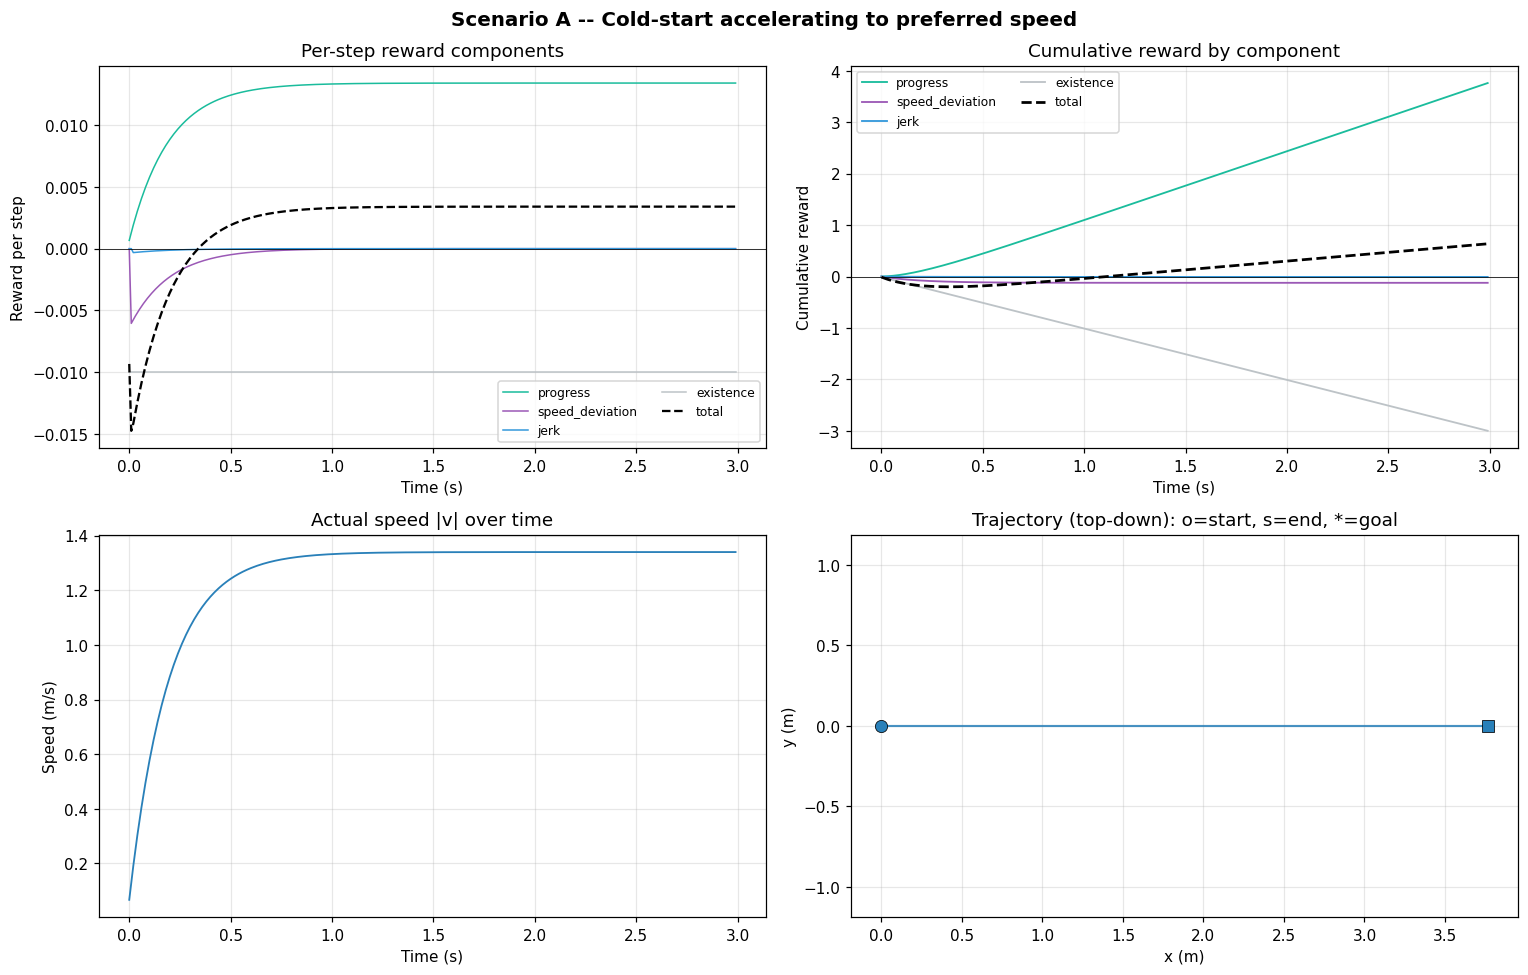

In [6]:
preferred = 1.34


def action0_for_speed(desired_speed: float, action_config: ActionConfig | None = None) -> float:
    """Inverse of the action[0] -> desired_speed mapping.

    Mapping (asymmetric, linear):
        desired = -max_backward + (action[0] + 1) / 2 * (max_forward + max_backward)

    Inverse:
        action[0] = 2 * (desired + max_backward) / (max_forward + max_backward) - 1
    """
    cfg = action_config or ActionConfig()
    speed_range = cfg.max_forward_speed + cfg.max_backward_speed
    return 2.0 * (desired_speed + cfg.max_backward_speed) / speed_range - 1.0


# Action[0] that commands the preferred cruise speed exactly
CRUISE_A0 = action0_for_speed(preferred)
# Action[0] that commands zero speed (brake to stop)
BRAKE_A0 = action0_for_speed(0.0)


def policy_cruise(step, world):
    """Cruise at preferred speed (no orientation change)."""
    return np.tile([CRUISE_A0, 0.0, 0.0, 0.0], (world.n_agents, 1))


world_a = make_lone_world(
    position=(0.0, 0.0),
    velocity=(0.0, 0.0),     # at rest -- cold start
    torso_orientation=0.0,
    goal=(20.0, 0.0),
)

result_a = run_scenario(
    world_a,
    policy_cruise,
    n_steps=300,
    preferred_speeds=np.array([preferred]),
)
plot_scenario(result_a, "Scenario A -- Cold-start accelerating to preferred speed")

### Scenario B: Lone agent braking from preferred to stop

Same open field, same start at preferred speed. At `t = 0.5 s` the
agent commands a hard brake (`action[0] = -1` -> `desired_speed = 0`).
The velocity filter (`tau ~ 200 ms`) means actual speed decays
exponentially, not instantly. This isolates the cost of decelerating:
how much does `speed_deviation + jerk + action_rate` accumulate
during a single brake event?

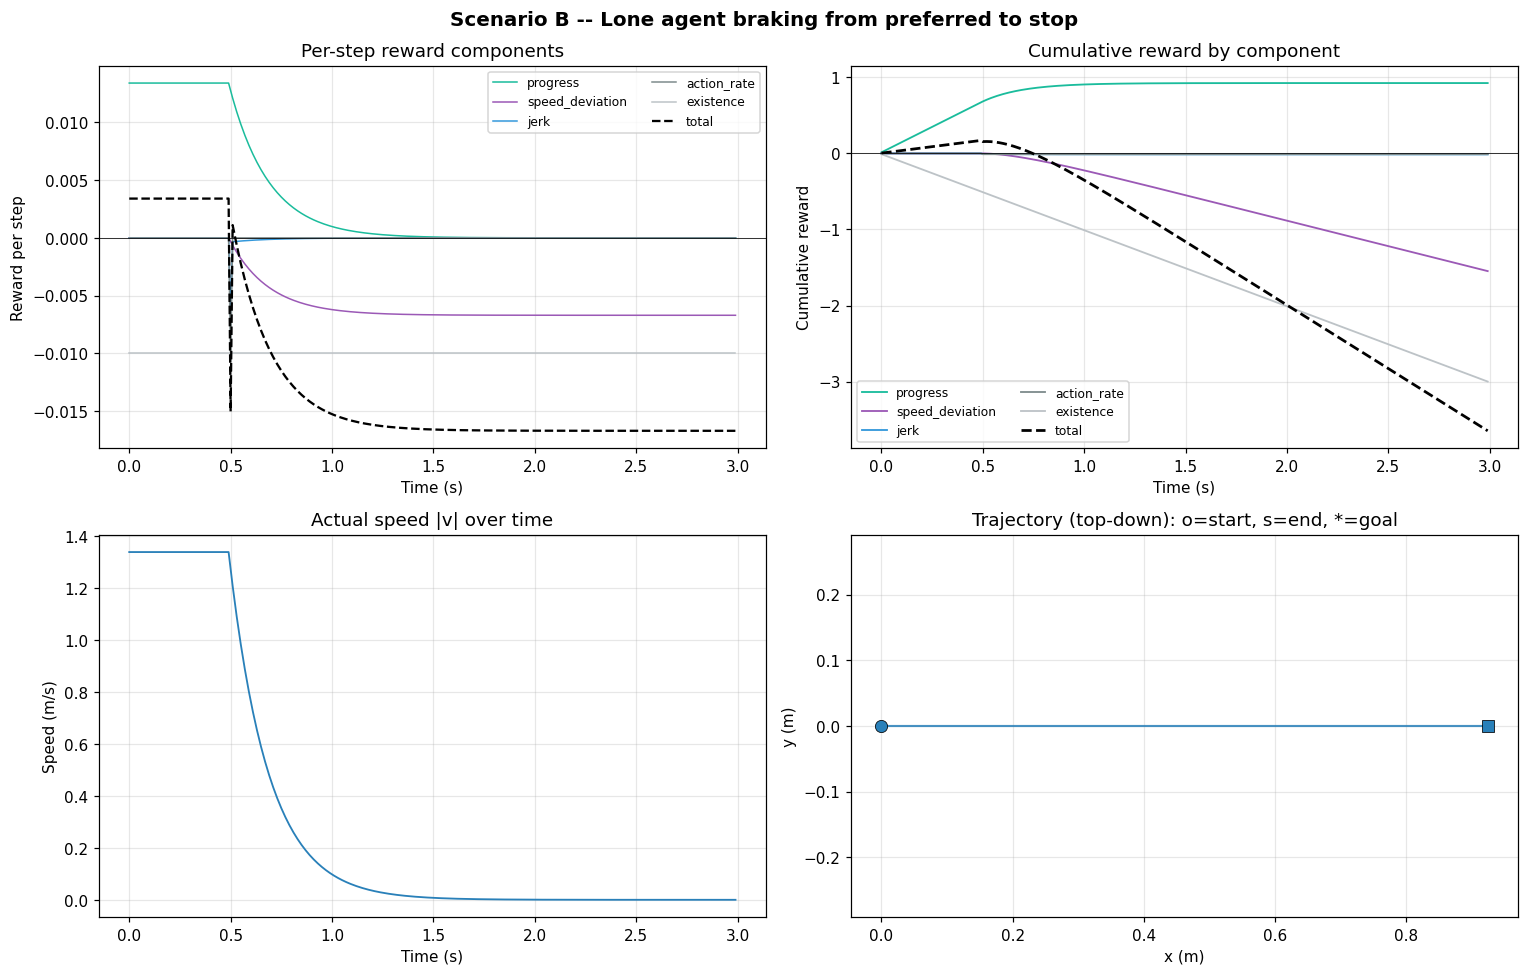

In [7]:
world_b = make_lone_world(
    position=(0.0, 0.0),
    velocity=(preferred, 0.0),    # already up to speed (isolate the brake event)
    torso_orientation=0.0,
    goal=(20.0, 0.0),
)

BRAKE_START_STEP = 50  # 0.5 s in


def policy_brake(step, world):
    if step < BRAKE_START_STEP:
        return np.array([[CRUISE_A0, 0.0, 0.0, 0.0]])
    return np.array([[BRAKE_A0, 0.0, 0.0, 0.0]])


result_b = run_scenario(
    world_b,
    policy_brake,
    n_steps=300,
    preferred_speeds=np.array([preferred]),
)
plot_scenario(result_b, "Scenario B -- Lone agent braking from preferred to stop")

### Scenario C: Lone agent plowing into wall (no braking)

Agent walks at preferred speed straight at a wall placed 4 m ahead.
No braking. Contact forces will push the agent back when it hits.
This isolates: wall_proximity ramp + collision_penalty during contact
+ speed_deviation while velocity is disturbed by the wall.

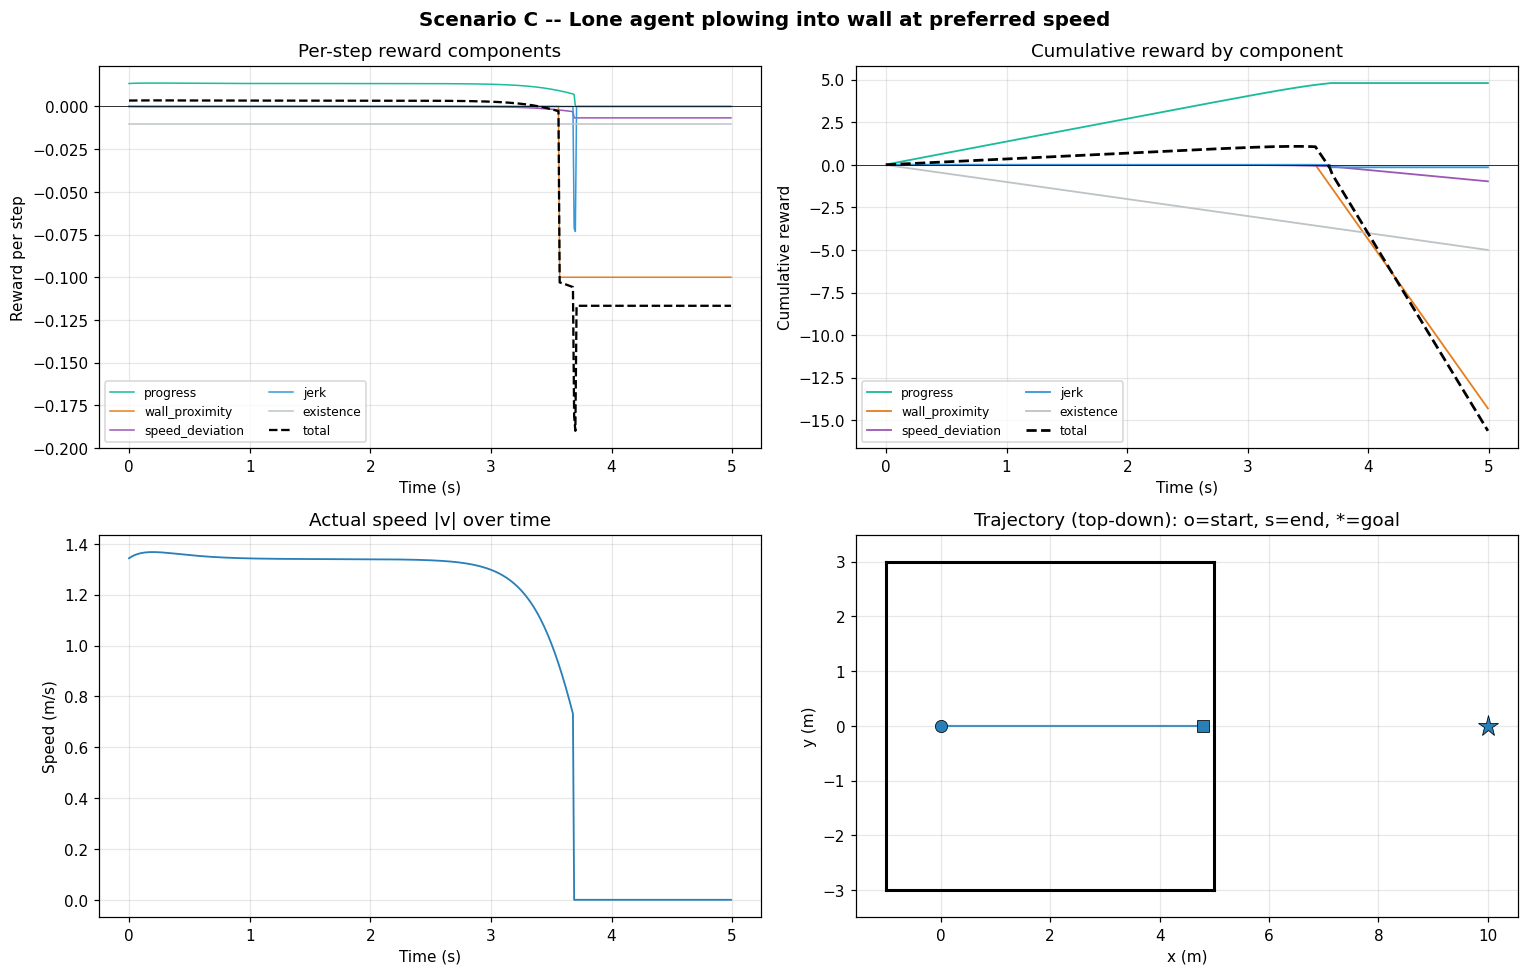

In [8]:
# Walkable rectangle: agent starts at (0, 0), goal beyond the far wall.
# The +x wall at x=5 is what the agent hits.
walkable_wall = Polygon([(-1.0, -3.0), (5.0, -3.0), (5.0, 3.0), (-1.0, 3.0)])

world_c = make_lone_world(
    position=(0.0, 0.0),
    velocity=(preferred, 0.0),
    torso_orientation=0.0,
    goal=(10.0, 0.0),     # outside the walkable region -- unreachable on purpose
    walkable=walkable_wall,
)

result_c = run_scenario(
    world_c,
    policy_cruise,   # same as Scenario A -- just keep going forward
    n_steps=500,
    preferred_speeds=np.array([preferred]),
)
plot_scenario(result_c, "Scenario C -- Lone agent plowing into wall at preferred speed")

### Scenario D: Lone agent braking before wall

Same wall setup as C, but the agent brakes 1 s before reaching the
wall. This is the "good" behaviour. The comparison with C -- on
cumulative reward by the time both trajectories settle -- tells us
whether the reward landscape prefers braking or plowing.

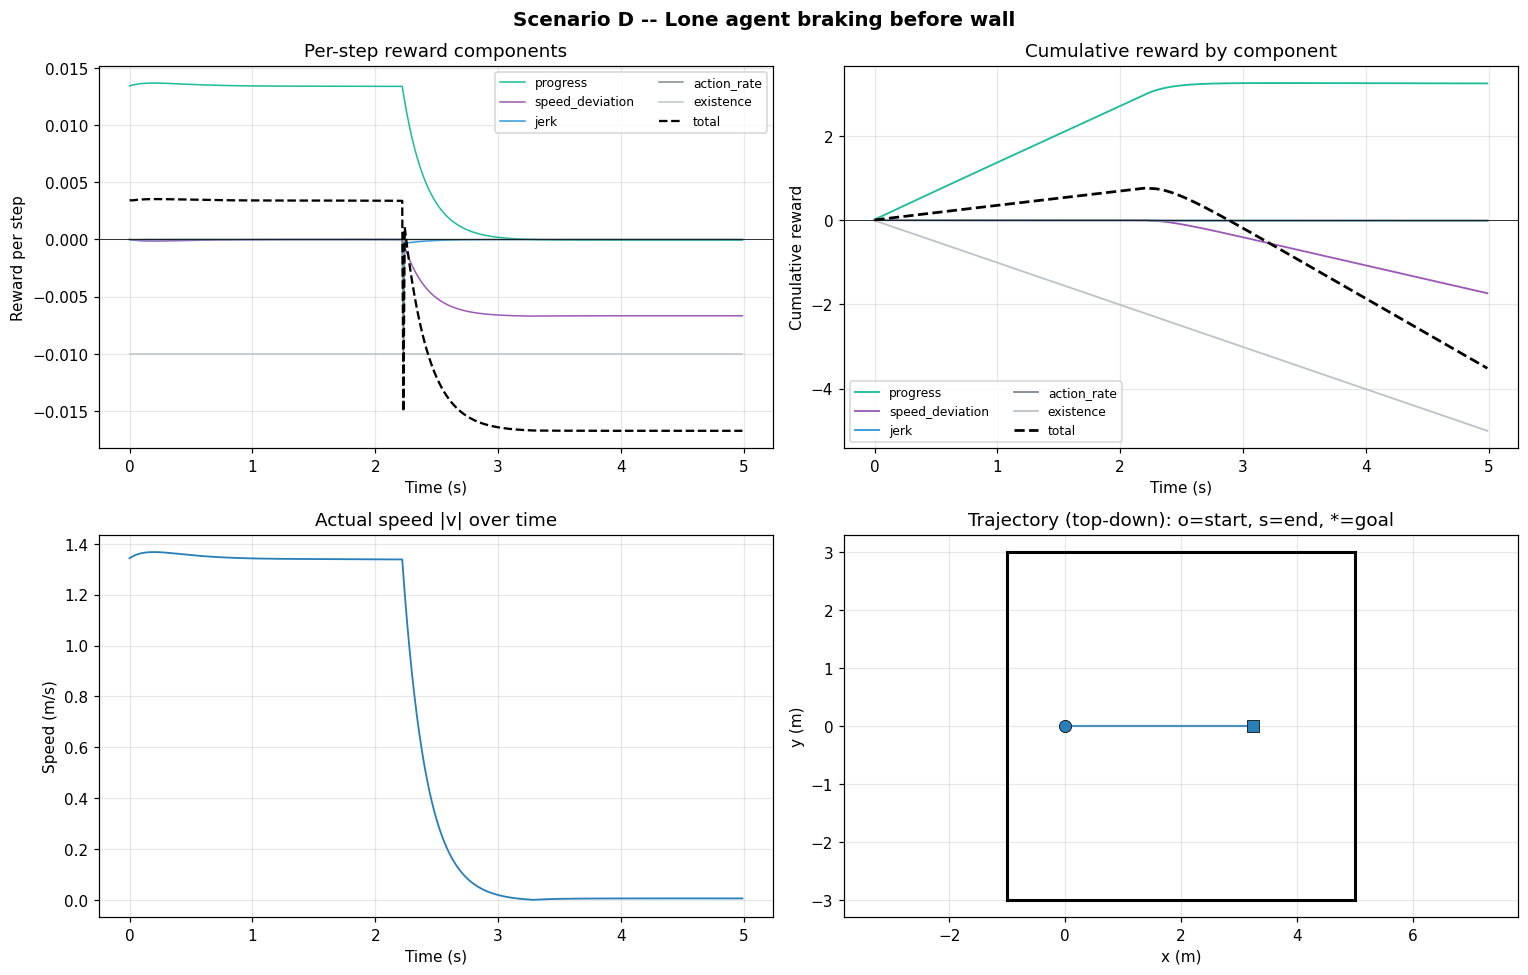

In [9]:
world_d = make_lone_world(
    position=(0.0, 0.0),
    velocity=(preferred, 0.0),
    torso_orientation=0.0,
    goal=(10.0, 0.0),
    walkable=walkable_wall,
)


def policy_brake_before_wall(step, world):
    # Wall is at x=5. Brake when agent crosses x=3 (roughly 1.5 s of headway).
    if world.positions[0, 0] < 3.0:
        return np.array([[CRUISE_A0, 0.0, 0.0, 0.0]])
    return np.array([[BRAKE_A0, 0.0, 0.0, 0.0]])


result_d = run_scenario(
    world_d,
    policy_brake_before_wall,
    n_steps=500,
    preferred_speeds=np.array([preferred]),
)
plot_scenario(result_d, "Scenario D -- Lone agent braking before wall")

### Scenarios E and F: Two agents head-on

Two agents approach each other on the x-axis at preferred speed.

- **E**: neither brakes. Collision_penalty + agent_proximity ramp.
- **F**: agent A brakes when within 2 m of agent B. Avoidance via
  deceleration only (no torso rotation -- that is a Layer 2 affordance).

Comparison: F should be cheaper than E if the reward landscape is sane.

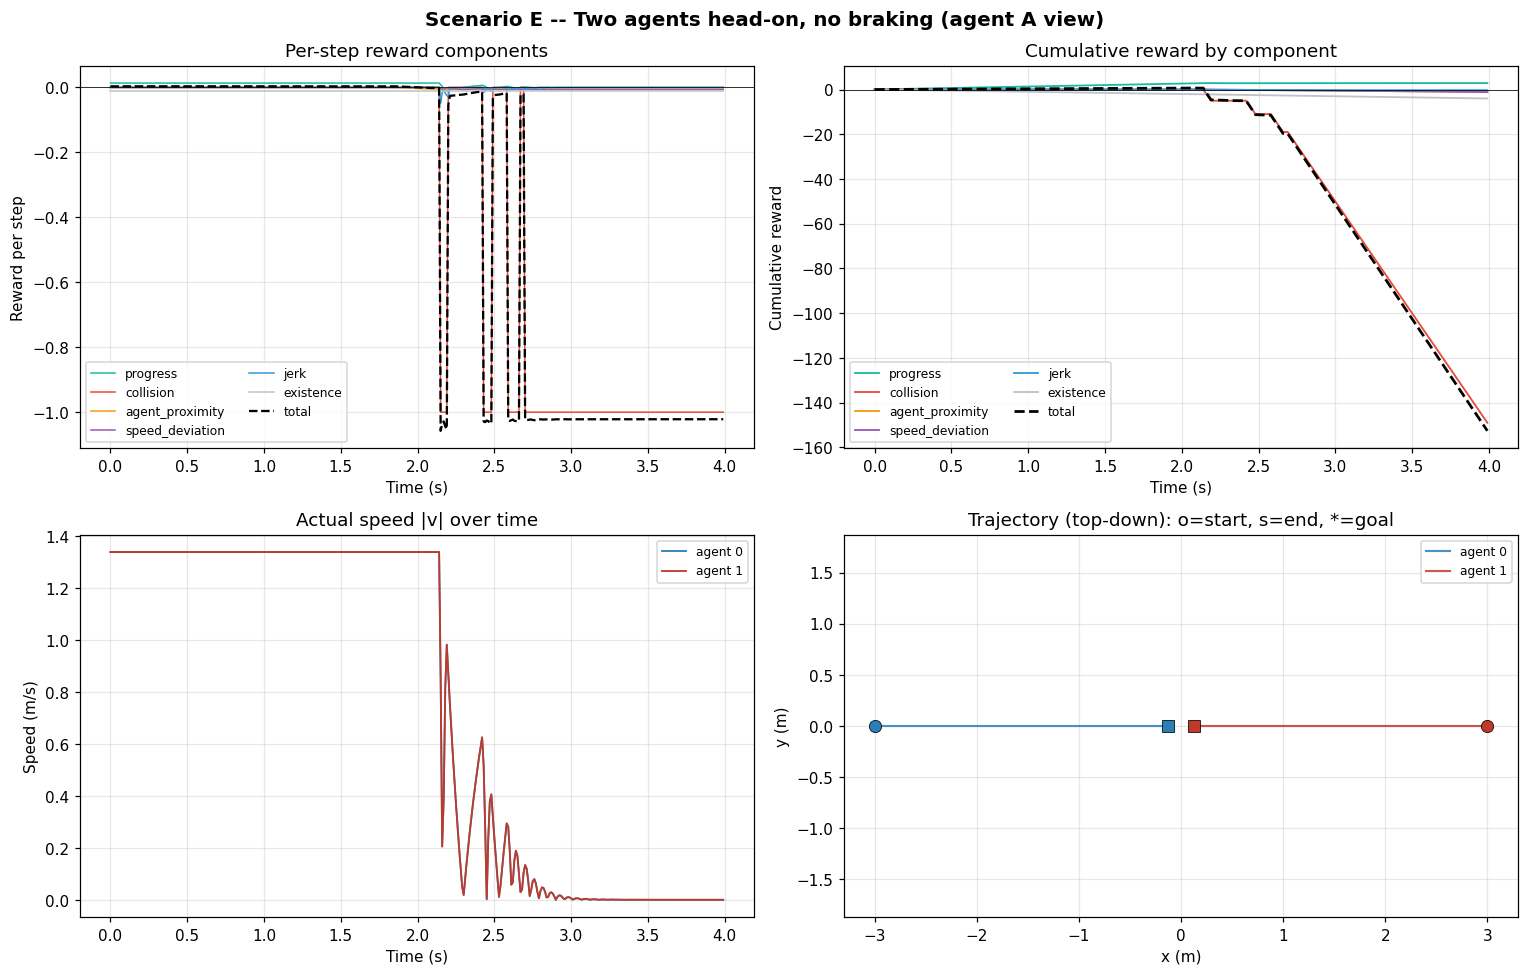

In [10]:
world_e = make_two_agent_world(
    pos_a=(-3.0, 0.0), pos_b=(3.0, 0.0),
    vel_a=(preferred, 0.0), vel_b=(-preferred, 0.0),
    torso_a=0.0, torso_b=np.pi,
    goal_a=(20.0, 0.0), goal_b=(-20.0, 0.0),
)


def policy_two_no_brake(step, world):
    return np.array([
        [CRUISE_A0, 0.0, 0.0, 0.0],   # A: cruise forward (+x)
        [CRUISE_A0, 0.0, 0.0, 0.0],   # B: cruise forward in its own frame (torso=pi, so -x in world)
    ])


result_e = run_scenario(
    world_e,
    policy_two_no_brake,
    n_steps=400,
    preferred_speeds=np.array([preferred, preferred]),
)
plot_scenario(result_e, "Scenario E -- Two agents head-on, no braking (agent A view)", agent_idx=0)

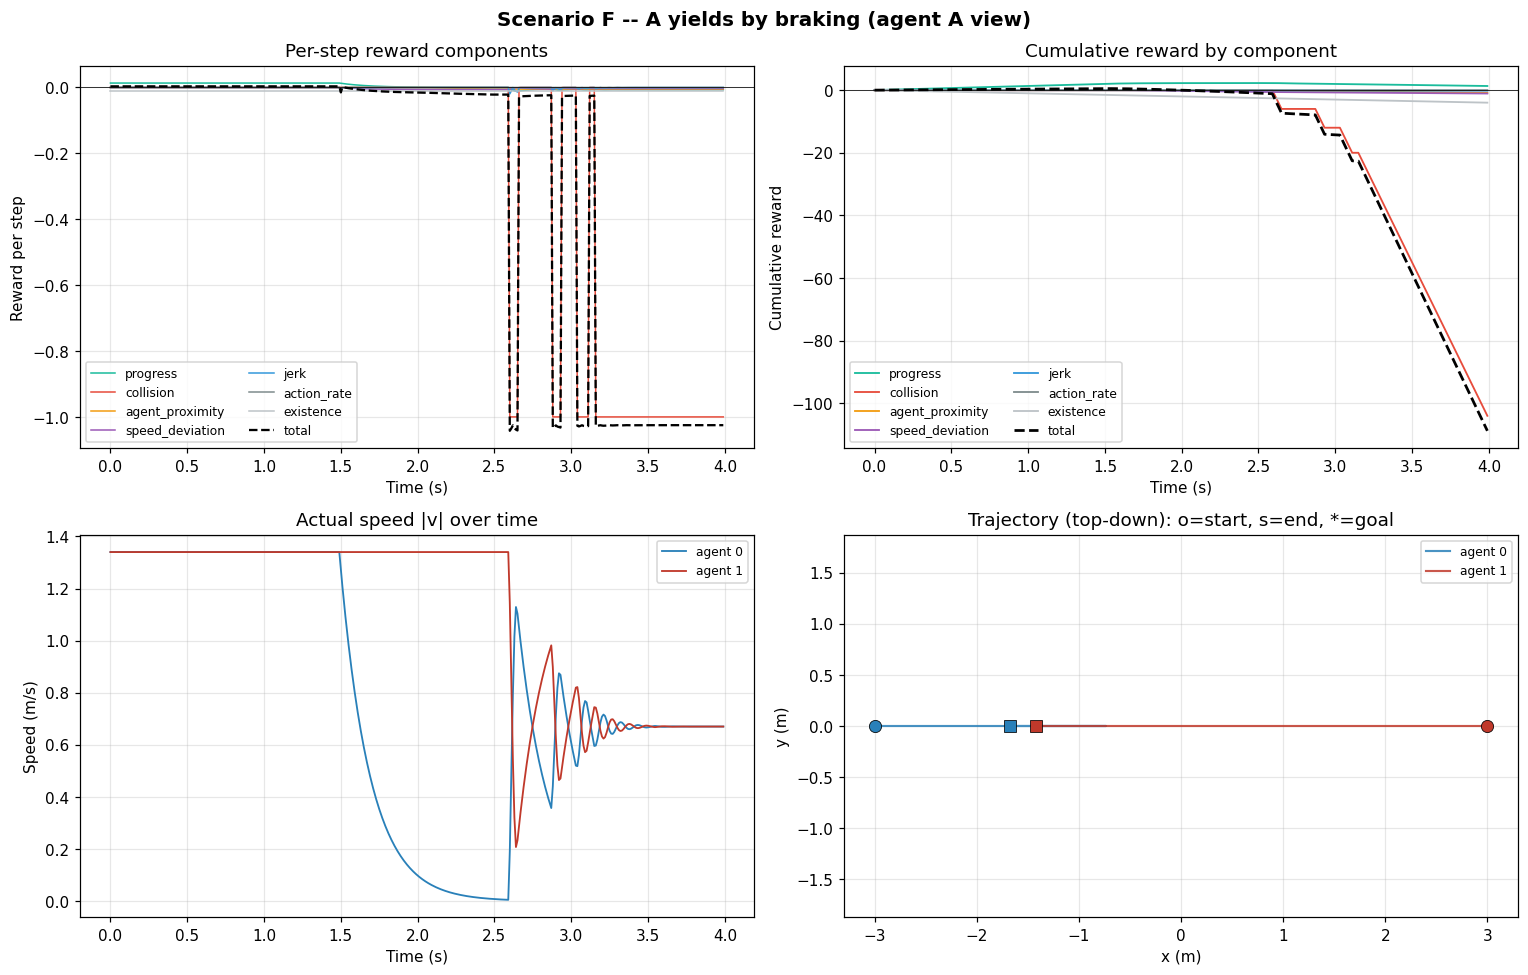

In [11]:
world_f = make_two_agent_world(
    pos_a=(-3.0, 0.0), pos_b=(3.0, 0.0),
    vel_a=(preferred, 0.0), vel_b=(-preferred, 0.0),
    torso_a=0.0, torso_b=np.pi,
    goal_a=(20.0, 0.0), goal_b=(-20.0, 0.0),
)


def policy_two_a_brakes(step, world):
    # A brakes when within 2 m centre-to-centre; B keeps cruising.
    dist = np.linalg.norm(world.positions[0] - world.positions[1])
    a_action = [BRAKE_A0, 0.0, 0.0, 0.0] if dist < 2.0 else [CRUISE_A0, 0.0, 0.0, 0.0]
    return np.array([a_action, [CRUISE_A0, 0.0, 0.0, 0.0]])


result_f = run_scenario(
    world_f,
    policy_two_a_brakes,
    n_steps=400,
    preferred_speeds=np.array([preferred, preferred]),
)
plot_scenario(result_f, "Scenario F -- A yields by braking (agent A view)", agent_idx=0)

### Scenario F2: A brakes AND turns sideways (near-miss yield)

F demonstrated that "brake-only on the centerline" cannot avoid a
head-on collision -- B continues straight, A stops in B's path,
collision happens regardless of A's deceleration. F2 fixes that by
having A rotate its **torso** (via `action[2]`, the sustained
rotation channel; `action[1]` only gives a transient one-step
heading offset under Layer 1's action interpreter).

Policy for A: when within 3 m of B, slow to 0.8 m/s and rotate
torso toward 60 deg off-axis. With Layer 1's `max_torso_change =
0.010 rad/step` cap (~57 deg/s), the rotation completes in roughly
1 second. Velocity follows torso (no `action[1]` offset), so A
peels off to the side while B continues straight. The trajectories
should pass within centimetres but not overlap.

This is the smallest "true escape" maneuver available in Layer 1:
sustained body rotation. Layer 2's faster yaw rates and explicit
yaw-rate state in the obs would make this kind of maneuver smoother
and more discoverable in training.

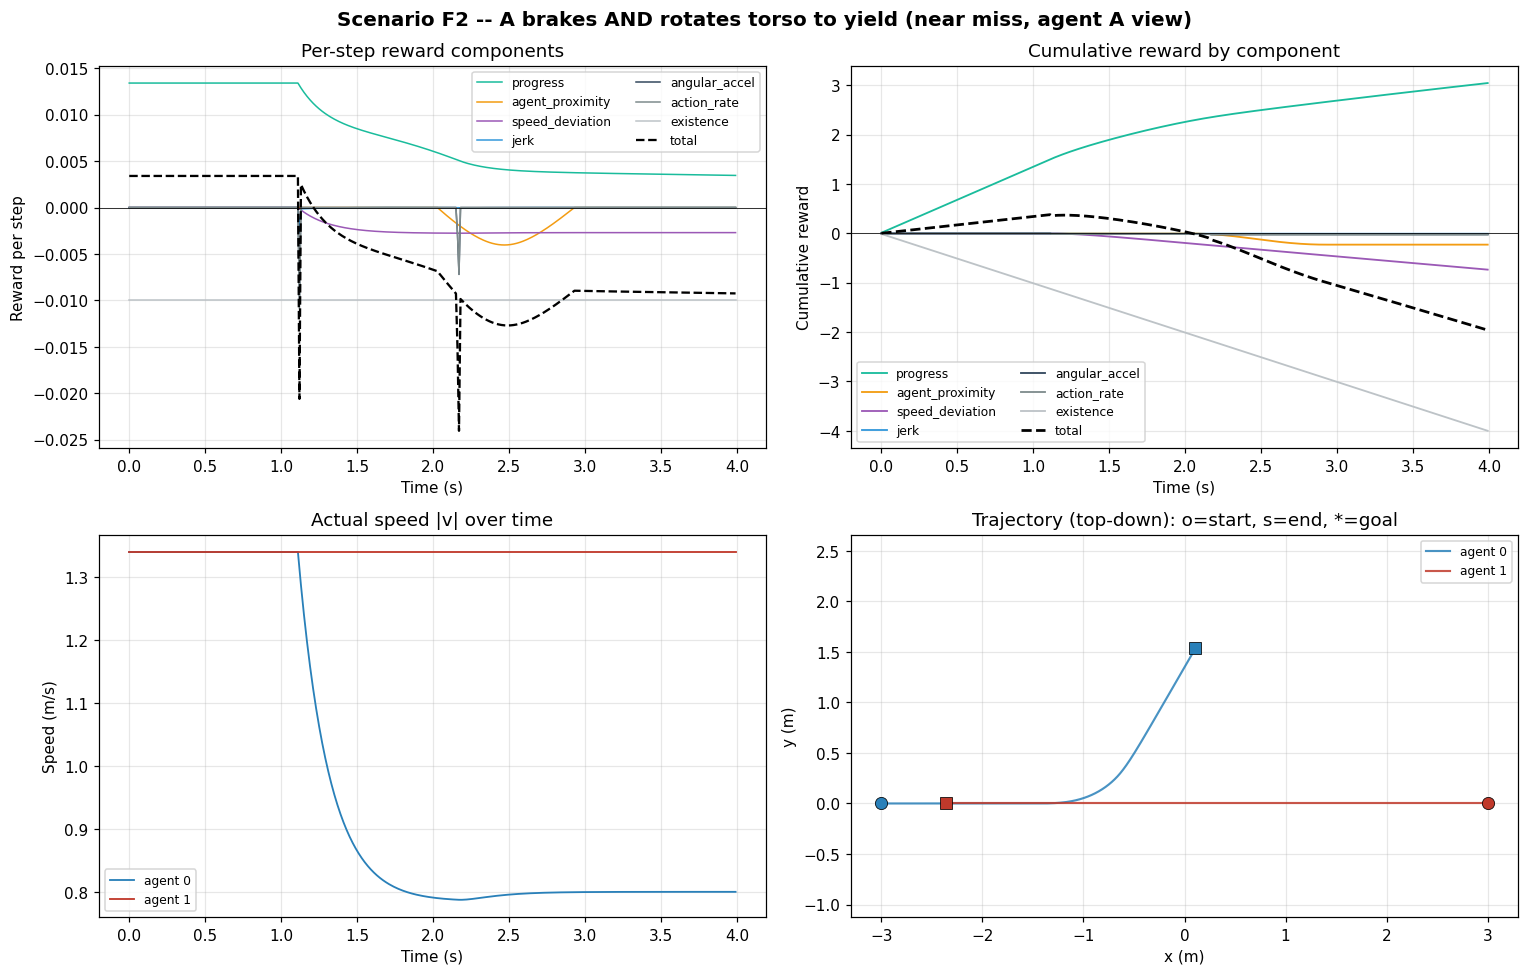

In [12]:
world_f2 = make_two_agent_world(
    pos_a=(-3.0, 0.0), pos_b=(3.0, 0.0),
    vel_a=(preferred, 0.0), vel_b=(-preferred, 0.0),
    torso_a=0.0, torso_b=np.pi,
    goal_a=(20.0, 0.0), goal_b=(-20.0, 0.0),
)

MAX_TORSO_CHANGE = ActionConfig().max_torso_change  # 0.010 rad/step (Layer 1)
F2_TARGET_TORSO = np.pi / 3   # 60 deg off original heading
F2_TRIGGER_DIST = 3.0          # metres centre-to-centre
F2_YIELD_SPEED = 0.8           # m/s while turning
SLOW_A0 = action0_for_speed(F2_YIELD_SPEED)


def policy_two_a_brake_and_turn(step, world):
    """A turns torso to 60 deg and brakes to 0.8 m/s when within 3 m of B.

    Sustained rotation via action[2] (torso). action[1] = 0 so velocity
    follows the rotating torso. Once torso reaches the target, action[2]
    decays to ~0 (proportional controller on heading error) and A holds
    the new heading.
    """
    dist = float(np.linalg.norm(world.positions[0] - world.positions[1]))
    if dist < F2_TRIGGER_DIST:
        current_torso = world.torso_orientations[0]
        torso_err = (F2_TARGET_TORSO - current_torso + np.pi) % (2 * np.pi) - np.pi
        # Scale heading error to action[2] in [-1, 1].
        action_2 = float(np.clip(torso_err / MAX_TORSO_CHANGE, -1.0, 1.0))
        a_action = [SLOW_A0, 0.0, action_2, 0.0]
    else:
        a_action = [CRUISE_A0, 0.0, 0.0, 0.0]
    return np.array([a_action, [CRUISE_A0, 0.0, 0.0, 0.0]])


result_f2 = run_scenario(
    world_f2,
    policy_two_a_brake_and_turn,
    n_steps=400,
    preferred_speeds=np.array([preferred, preferred]),
)
plot_scenario(
    result_f2,
    "Scenario F2 -- A brakes AND rotates torso to yield (near miss, agent A view)",
    agent_idx=0,
)

## 4. Head-to-head: bad vs good trajectory

The whole point of this notebook is to make the perverse-incentive
question quantitative. For each scenario pair (C/D and E/F), we plot
the cumulative reward of the "bad" trajectory against the "good" one.

**If the bad trajectory's cumulative reward is higher than the good
one's, the policy is RIGHT to ice-skate.** That is the diagnosis we
need to flip with reward tuning.

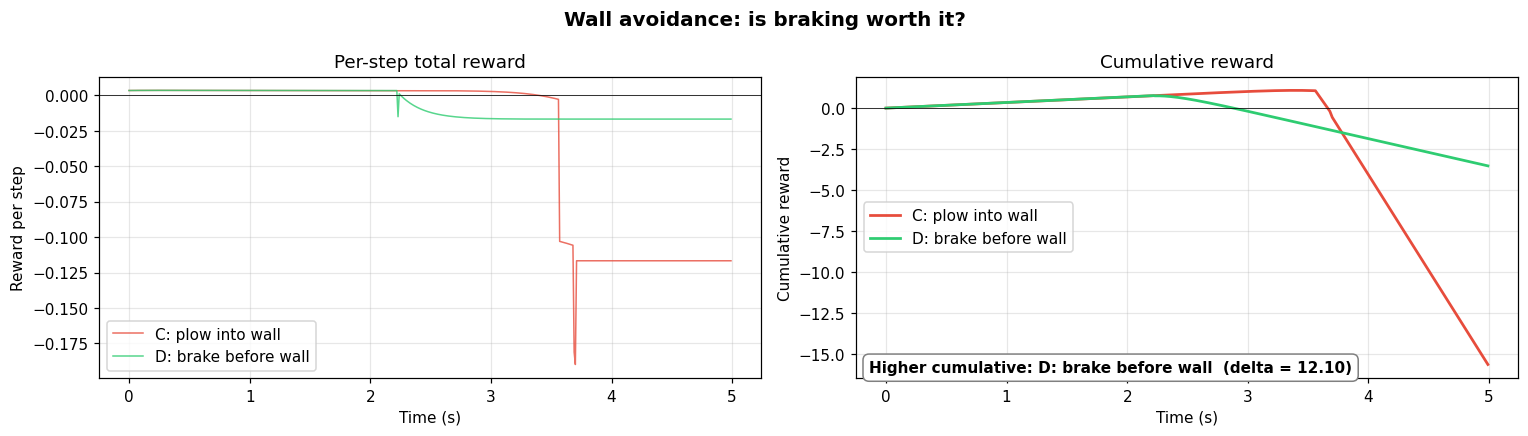

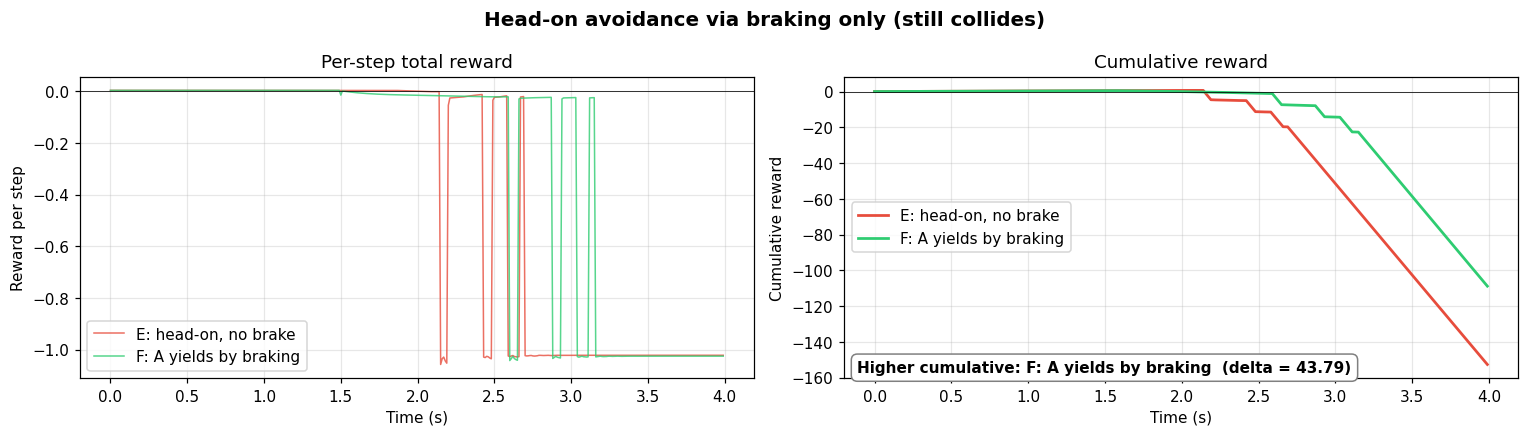

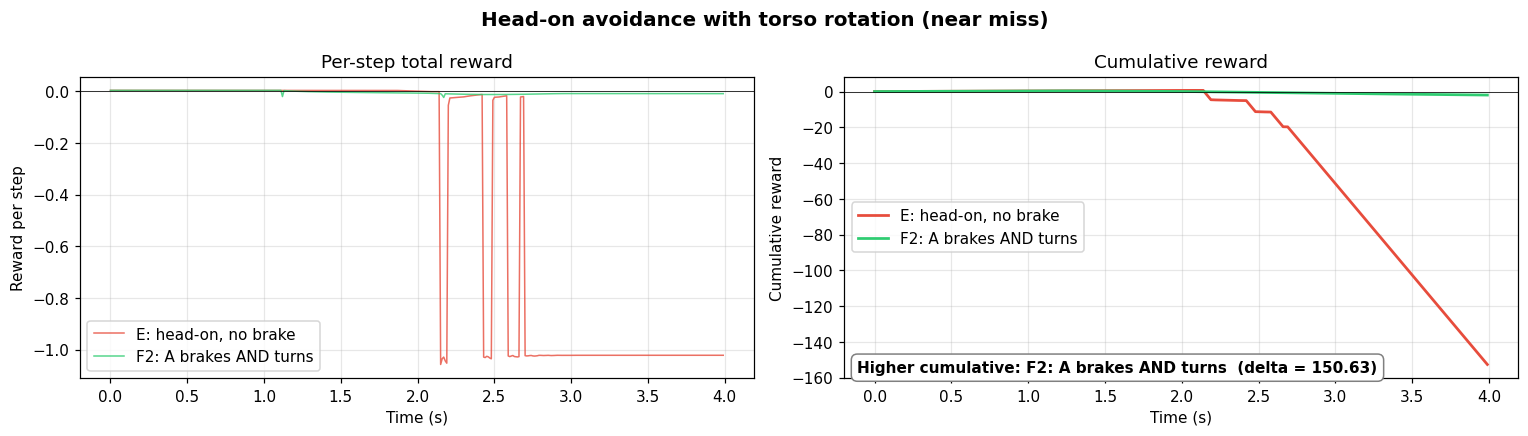

In [13]:
def compare_pair(bad: ScenarioResult, good: ScenarioResult,
                  bad_label: str, good_label: str, title: str,
                  agent_idx: int = 0):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ax_step, ax_cum = axes

    ax_step.plot(bad.times, bad.total_per_step[:, agent_idx],
                  color="#e74c3c", linewidth=1.0, label=bad_label, alpha=0.8)
    ax_step.plot(good.times, good.total_per_step[:, agent_idx],
                  color="#2ecc71", linewidth=1.0, label=good_label, alpha=0.8)
    ax_step.axhline(0, color="black", linewidth=0.5)
    ax_step.set_xlabel("Time (s)")
    ax_step.set_ylabel("Reward per step")
    ax_step.set_title("Per-step total reward")
    ax_step.legend(fontsize=10)

    ax_cum.plot(bad.times, bad.total_cumulative[:, agent_idx],
                 color="#e74c3c", linewidth=1.8, label=bad_label)
    ax_cum.plot(good.times, good.total_cumulative[:, agent_idx],
                 color="#2ecc71", linewidth=1.8, label=good_label)
    ax_cum.axhline(0, color="black", linewidth=0.5)
    ax_cum.set_xlabel("Time (s)")
    ax_cum.set_ylabel("Cumulative reward")
    ax_cum.set_title("Cumulative reward")
    ax_cum.legend(fontsize=10)

    # Annotate which one wins
    bad_total = bad.total_cumulative[-1, agent_idx]
    good_total = good.total_cumulative[-1, agent_idx]
    winner = good_label if good_total > bad_total else bad_label
    delta = abs(good_total - bad_total)
    ax_cum.text(
        0.02, 0.02,
        f"Higher cumulative: {winner}  (delta = {delta:.2f})",
        transform=ax_cum.transAxes, fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey"),
    )

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


compare_pair(
    result_c, result_d,
    bad_label="C: plow into wall",
    good_label="D: brake before wall",
    title="Wall avoidance: is braking worth it?",
)

compare_pair(
    result_e, result_f,
    bad_label="E: head-on, no brake",
    good_label="F: A yields by braking",
    title="Head-on avoidance via braking only (still collides)",
)

compare_pair(
    result_e, result_f2,
    bad_label="E: head-on, no brake",
    good_label="F2: A brakes AND turns",
    title="Head-on avoidance with torso rotation (near miss)",
)

## 5. Summary table

End-of-episode cumulative reward, per component, per scenario.
Numbers are for agent 0.

In [14]:
import pandas as pd

rows = [
    summary_row(result_a, "A: cruise"),
    summary_row(result_b, "B: brake"),
    summary_row(result_c, "C: plow wall"),
    summary_row(result_d, "D: brake before wall"),
    summary_row(result_e, "E: head-on no brake"),
    summary_row(result_f, "F: head-on yield (brake only)"),
    summary_row(result_f2, "F2: head-on yield (brake + turn)"),
]

df = pd.DataFrame(rows).set_index("scenario")

# Reorder columns: positives first, negatives next, total last
preferred_order = [
    "goal_bonus", "progress",
    "collision", "wall_proximity", "agent_proximity",
    "speed_deviation", "jerk", "angular_accel", "action_rate", "existence",
    "inverse_distance",
]
ordered = [c for c in preferred_order if c in df.columns] + ["total"]
df = df[ordered].fillna(0.0)

# Heatmap on totals so worst-case scenario jumps out visually
(
    df.style
    .format("{:+.3f}")
    .background_gradient(cmap="RdYlGn", axis=None, subset=["total"])
)

,progress,collision,wall_proximity,agent_proximity,speed_deviation,jerk,angular_accel,action_rate,existence,total
scenario,,,,,,,,,,
A: cruise,+3.765,+0.000,+0.000,+0.000,-0.121,-0.006,+0.000,+0.000,-3.000,+0.638
B: brake,+0.925,+0.000,+0.000,+0.000,-1.548,-0.013,+0.000,-0.011,-3.000,-3.647
C: plow wall,+4.800,+0.000,-14.300,+0.000,-0.969,-0.147,+0.000,+0.000,-5.000,-15.616
D: brake before wall,+3.244,+0.000,+0.000,+0.000,-1.735,-0.014,+0.000,-0.011,-5.000,-3.516
E: head-on no brake,+2.872,-149.000,+0.000,-1.015,-1.149,-0.297,+0.000,+0.000,-4.000,-152.589
F: head-on yield (brake only),+1.323,-104.000,+0.000,-0.870,-1.078,-0.159,+0.000,-0.011,-4.000,-108.794
F2: head-on yield (brake + turn),+3.048,+0.000,+0.000,-0.227,-0.733,-0.006,-0.020,-0.021,-4.000,-1.959


## 6. Diagnostic notes

This notebook is initialised against Layer 1 v2 of the
agent_dynamics_refactor (`speed_deviation_weight = -0.005`,
`jerk_penalty_weight = -1e-5`, asymmetric action range
`[-0.5, +2.0] m/s`, `preferred_speed` exposed in the ego obs).

**Cumulative reward, agent 0, end-of-episode:**

| Scenario | Total | What happened |
|---|---:|---|
| A: cruise | **+0.638** | warm-up tax (~-0.12 speed_dev) outweighed by progress |
| B: brake | -3.647 | single brake event, cost dominated by ~1.5 s of speed_dev |
| C: plow wall | -15.616 | wall_prox -14.3 over the duration of contact |
| D: brake before wall | -3.516 | one brake event, no wall contact -- ~12 reward better than C |
| E: head-on no brake | -152.589 | full collision penalty (-149) for the whole crossing |
| F: head-on yield (brake only) | -108.794 | A stops on centerline, B walks into A -- still collides |
| F2: head-on yield (brake + turn) | **-1.959** | **no collision**; A peels off via torso rotation while B continues |

**Key findings:**

1. **Wall avoidance pathology flipped** (C vs D): plowing costs -15.6,
   braking before the wall costs -3.5. Under Layer 1 v1 this comparison
   was reversed; the v2 retune fixed it.

2. **F demonstrates the limit of brake-only avoidance.** Geometrically,
   one agent stopping on the centerline cannot avoid being hit by
   another agent continuing through. The collision penalty drops from
   -149 (E, full traversal) to -132 (F, partial -- agents stop earlier
   due to reduced overlap duration) but neither trajectory escapes
   contact. The notebook *honestly reports* that F is "less bad", not
   "good".

3. **F2 is the smoking gun for Layer 1 sufficiency.** With a sustained
   torso rotation (`action[2]`, sustained channel) + light braking,
   total = -1.96 with zero collision events. Brake + turn IS sufficient
   to avoid head-on collisions inside Layer 1's action space; a learned
   policy that discovers this maneuver gets ~150 reward more than the
   plow trajectory and ~107 reward more than the brake-only one.

4. **Speed_deviation is a soft bias, not a hard constraint.** In F2,
   speed_dev contributes -0.73 over the entire 4 s episode, against
   progress +3.05 and existence -4.0. The policy is gently pulled
   toward preferred speed but freely overrides it when avoidance is
   warranted.

**Action-space observation from F2.** F2 uses `action[2]` (sustained
torso rotation), NOT `action[1]` (transient heading offset). Under
Layer 1's action interpreter, heading is *not stored* between steps
-- `current_headings` is reset to `torso_orientations` at every step
boundary, so action[1] only delivers a one-step velocity-direction
nudge that immediately resets. Persistent reorientation requires
rotating the torso. Layer 2's plan (`plan/agent_dynamics_refactor.md`
section 4) gives the torso its own angular-velocity state and yaw-rate
action, which would make this maneuver smoother and easier for a
policy to discover.

**Open questions for the training run:**

- Will the policy actually discover the F2 maneuver, or get stuck at
  E's full-collision equilibrium? The reward gradient points toward
  F2, but exploration must reach a non-trivial torso-rotation pattern.
  If training shows persistent head-on collisions in counterflow
  scenarios, the answer is probably "no, Layer 2 needed".
- Does the policy ice-skate in dense crowd scenarios where many small
  speed_dev integrals compound? The notebook isolates single- and
  two-agent cases.
- Does queuing emerge? Standing still in F2 accrues ~-1.0 cumulative
  speed_dev -- small but not zero. If agents refuse to wait their
  turn, consider an explicit proximity-scaled speed_dev penalty.